# 06 - Stage 4 Label Generation QA

Visual checks on the per-tile label parquets in `dataset/labels/{ObsId}.parquet`.
Per the 2026-05-23 decisions:
- Mask coverage threshold = 1.0 (strict).
- Stage 3 (dx, dy) shifts applied to polygons before rasterization.
- No `min_confidence` filter yet -- tuned after looking at the histograms here.
- ESP_057469_2215 dropped from the sweep (tile-straddle, 0.1% HiRISE coverage).

All real logic lives in `src/labeling.py`. This notebook only loads the cached parquets and plots.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import manifest as M
from src.config import load_config
from src.ctx_retrieve import CTX_WINDOWS_SUBDIR
from src.labeling import LABELS_SUBDIR, load_labels, load_provenance

FIG_DIR = REPO_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_config(REPO_ROOT / 'config.yaml')
manifest_df = M.load_manifest(cfg.manifest_path)

obs_ids = []
for obs in manifest_df['ObsId']:
    if (cfg.output_dir / LABELS_SUBDIR / f'{obs}.parquet').exists():
        obs_ids.append(obs)
print(f'{len(obs_ids)} ObsIds with Stage 4 outputs: {obs_ids}')

9 ObsIds with Stage 4 outputs: ['ESP_055714_2270', 'ESP_054857_2270', 'ESP_069669_2220', 'ESP_071093_2210', 'ESP_047976_2020', 'ESP_056165_2200', 'ESP_075577_2105', 'ESP_039820_1750', 'ESP_065711_1545']


## Per-image label summary

One row per ObsId. Columns:
- `n_polys` -- BoulderNet polygons that passed Stage 4 filters (currently none filtered).
- `eligible_S{px}` -- tiles emitted at each scale (mask coverage == 1.0, all sub-tiles eligible for coarser scales).
- `frac_mean_S8`, `frac_p99_S8` -- mean and 99th percentile fractional_area on the finest scale.
- `shift_m`, `peak` -- Stage 3 metric applied to polygons before rasterization.

In [2]:
rows = []
for obs in obs_ids:
    prov = load_provenance(obs, cfg.output_dir)
    df = load_labels(obs, cfg.output_dir)
    finest = df[df['tile_size_px'] == prov['tile_sizes_px'][0]]
    row = {
        'ObsId': obs,
        'label': manifest_df.set_index('ObsId').loc[obs, 'BoulderLabel'],
        'n_polys': prov['n_polygons_after_filter'],
    }
    for s, n in sorted(prov['eligible_tiles_per_scale'].items()):
        row[f'eligible_S{s}'] = n
    row['frac_mean_S8'] = float(finest['fractional_area'].mean())
    row['frac_p99_S8'] = float(finest['fractional_area'].quantile(0.99))
    row['binary_area_rate_S8'] = float(finest['binary_by_area'].mean())
    row['binary_count_rate_S8'] = float(finest['binary_by_count'].mean())
    if prov['coreg_shift_applied'] and prov['coreg_shift_m']:
        row['shift_m'] = prov['coreg_shift_m']['magnitude']
        row['peak'] = prov['coreg_peak_correlation']
    rows.append(row)
summary = pd.DataFrame(rows).set_index('ObsId')
summary

,label,n_polys,eligible_S16,eligible_S32,eligible_S64,eligible_S8,frac_mean_S8,frac_p99_S8,binary_area_rate_S8,binary_count_rate_S8,shift_m,peak
ObsId,,,,,,,,,,,,
ESP_055714_2270,Boulder rich,1974,18819,4609,1100,76030,0.000554,0.015000,0.014928,0.000592,240.781995,0.599243
ESP_054857_2270,Boulder rich,6462,9068,2096,419,37292,0.001106,0.016875,0.082028,0.000241,118.006020,0.630957
ESP_069669_2220,Boulder rich,1462,18043,4428,1062,72821,0.000099,0.001250,0.005411,0.000865,272.576124,0.875339
ESP_071093_2210,Boulder rich,961,13834,3370,792,55962,0.000100,0.003750,0.008363,0.000125,246.985578,0.773468
ESP_047976_2020,Boulder rich,1346,13363,3259,773,54054,0.000080,0.002500,0.004810,0.000463,125.520768,0.713709
ESP_056165_2200,Boulder poor,26,17411,3901,756,73335,0.000001,0.000000,0.000082,0.000000,164.537909,0.281660
ESP_075577_2105,Boulder poor,624,11018,2691,639,44560,0.000051,0.000000,0.003142,0.000449,160.330869,0.686268
ESP_039820_1750,unknown,497,12162,2953,687,49279,0.000073,0.000000,0.004282,0.000041,178.920855,0.680477
ESP_065711_1545,unknown,0,6226,1518,359,25221,0.000000,0.000000,0.000000,0.000000,223.428939,0.701863


## Per-tile fractional_area heatmap

For each ObsId, render the finest-grid `fractional_area` as a 2-D heatmap (log-scaled,
since the distribution is extremely right-skewed and zero-inflated -- CLAUDE.md Section 9).
Tiles ineligible due to incomplete HiRISE coverage are left blank (not zero).

Two scales side-by-side: finest (8 px = 40 m) and coarsest (64 px = 320 m). The coarser
scale should look like a downsampled version of the finer one -- this is the visual form of
the nested-grid consistency property.

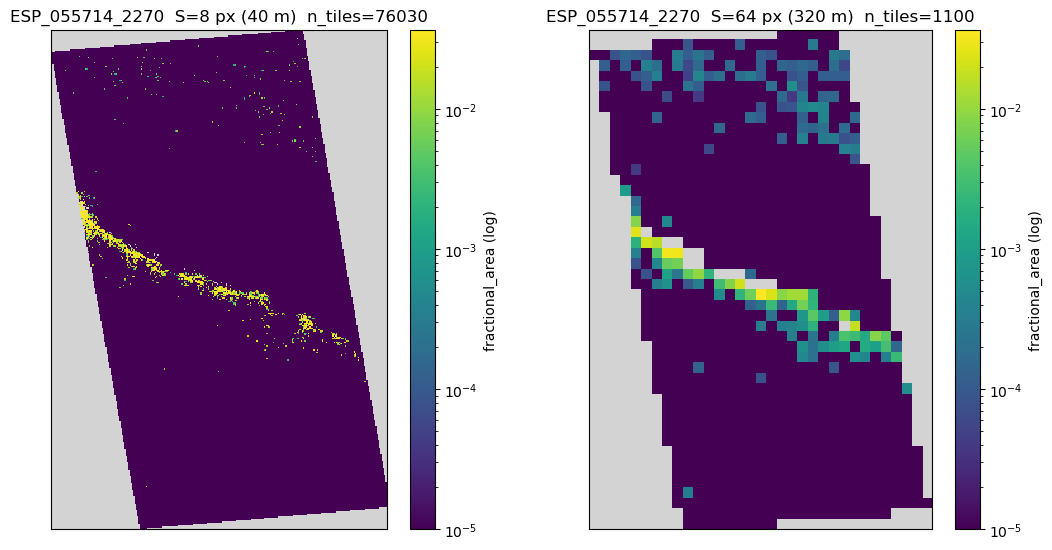

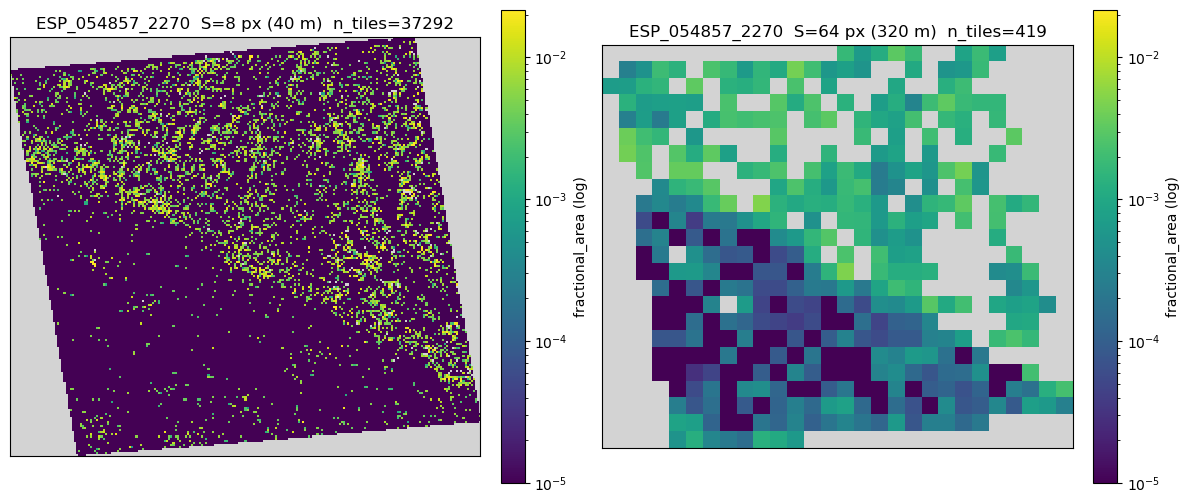

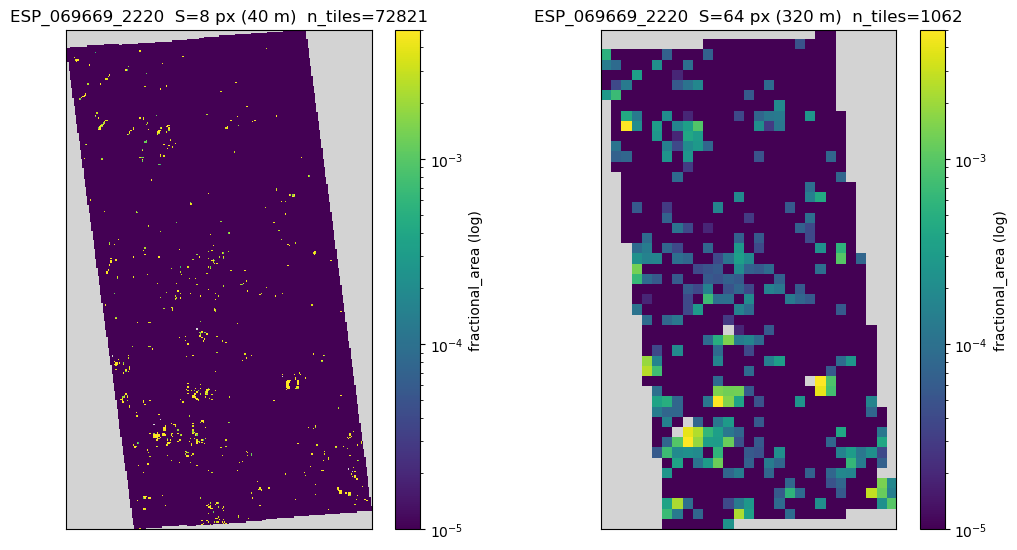

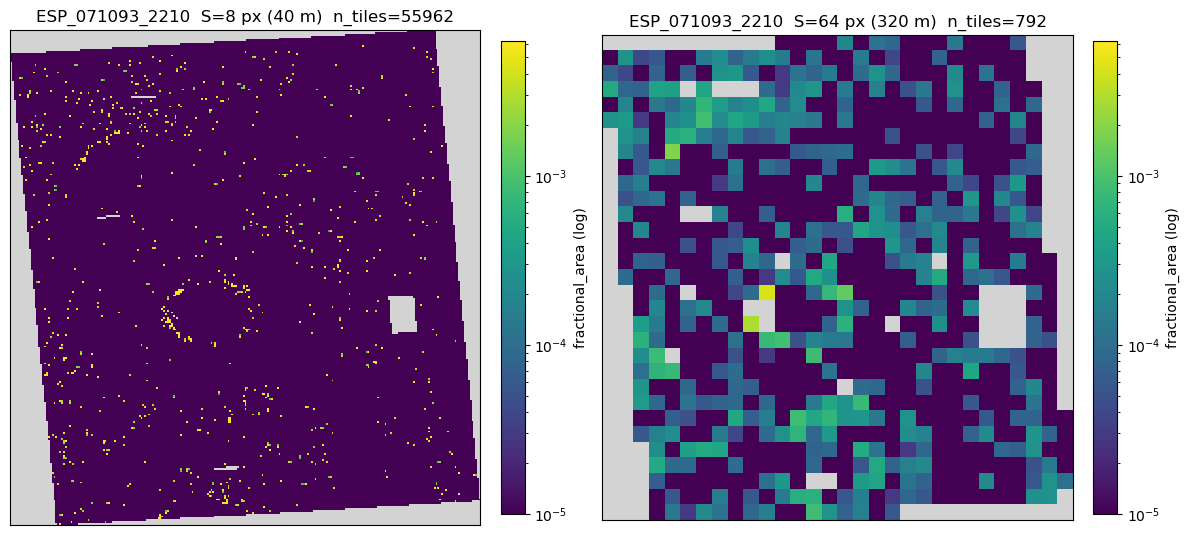

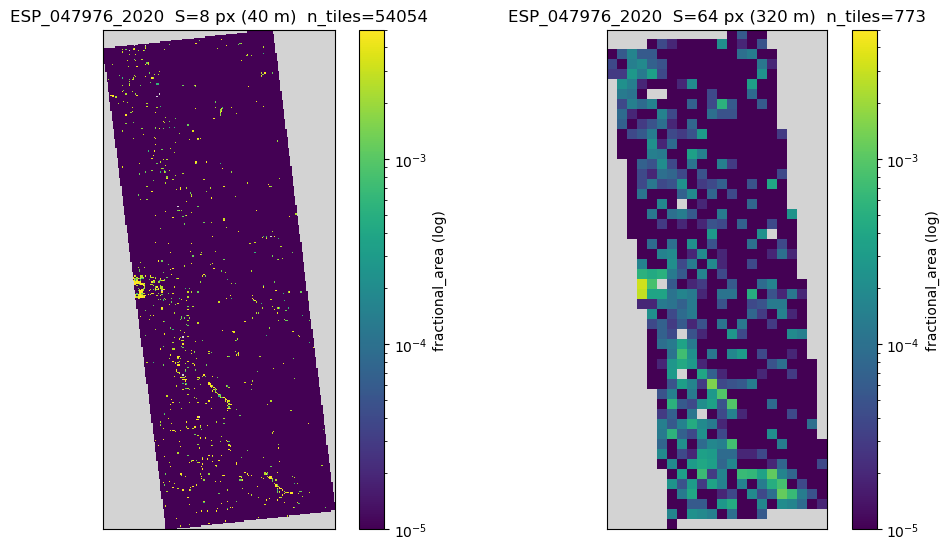

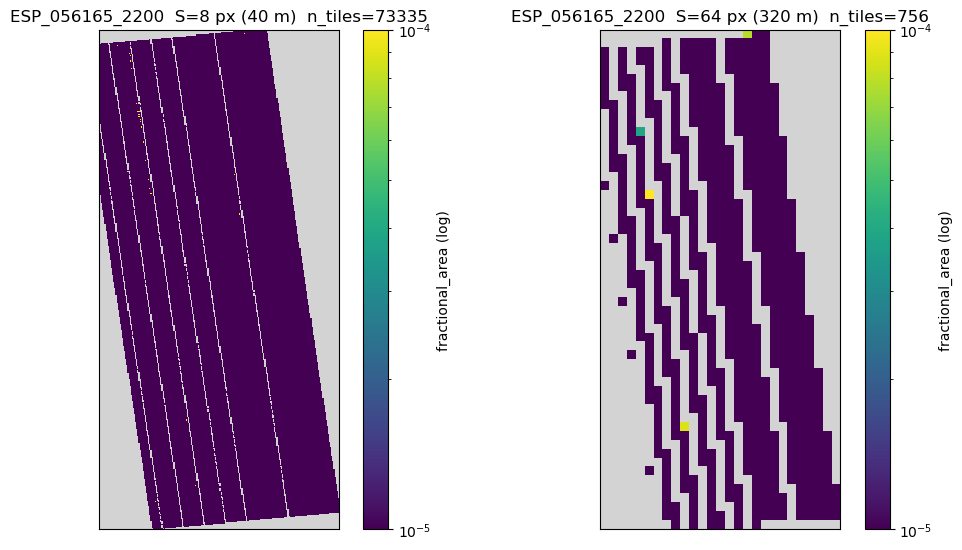

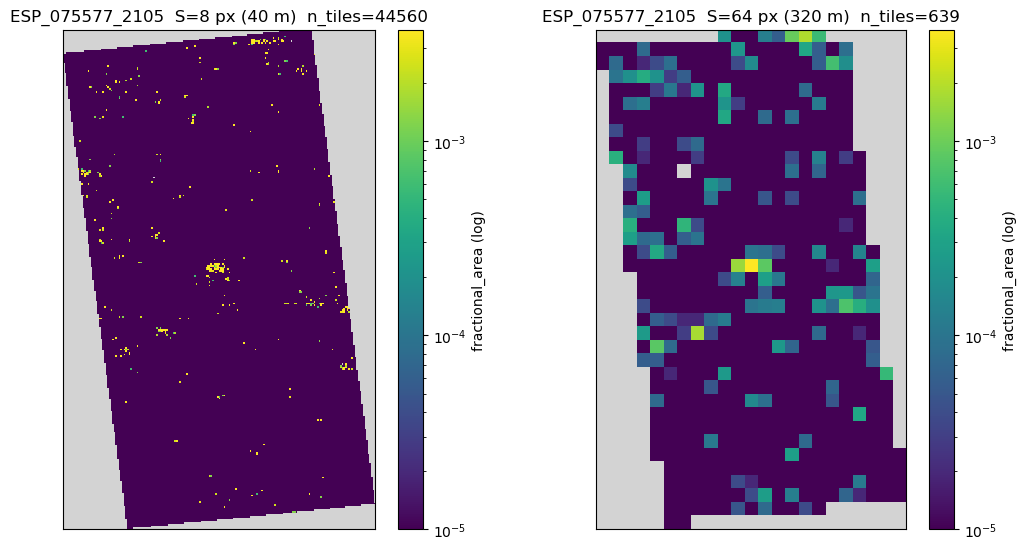

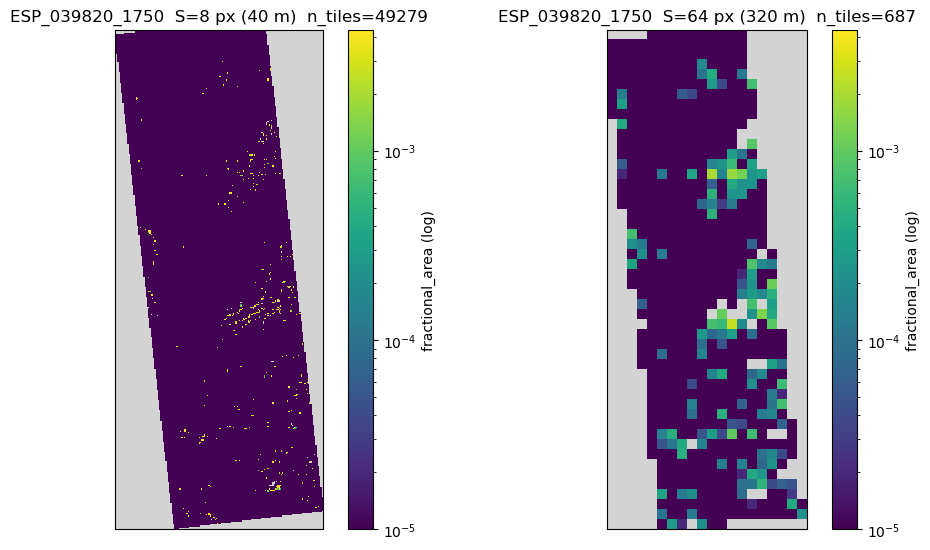

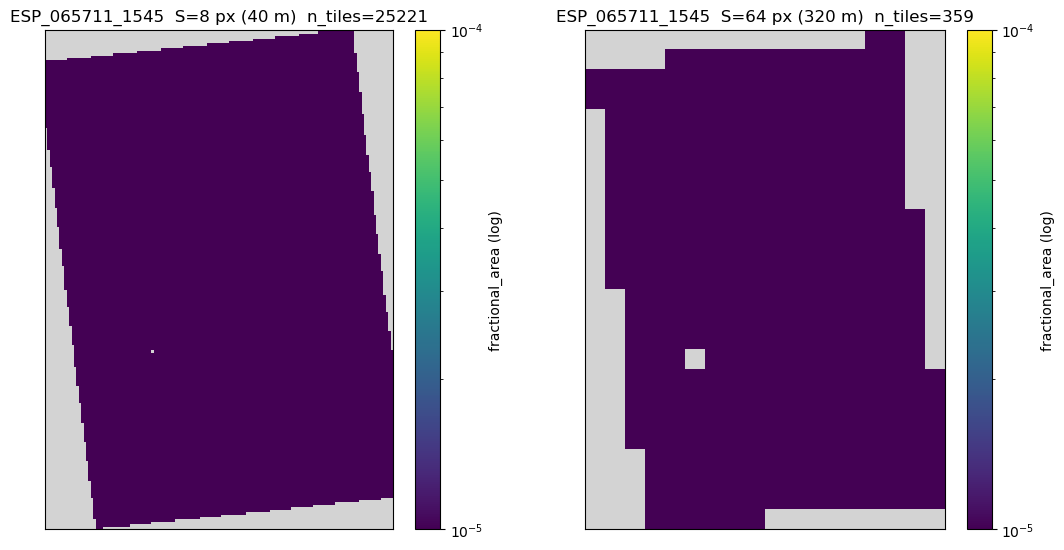

In [3]:
def plot_fractional_area_heatmap(obs_id: str) -> Path | None:
    df = load_labels(obs_id, cfg.output_dir)
    if len(df) == 0:
        return None
    prov = load_provenance(obs_id, cfg.output_dir)
    sizes = sorted(prov['tile_sizes_px'])
    finest, coarsest = sizes[0], sizes[-1]

    def render(scale_px):
        sub = df[df['tile_size_px'] == scale_px]
        if len(sub) == 0:
            return None, None, None
        ti_min, ti_max = int(sub['ti'].min()), int(sub['ti'].max())
        tj_min, tj_max = int(sub['tj'].min()), int(sub['tj'].max())
        grid = np.full((ti_max - ti_min + 1, tj_max - tj_min + 1), np.nan, dtype=np.float64)
        rs = sub['ti'].to_numpy() - ti_min
        cs = sub['tj'].to_numpy() - tj_min
        grid[rs, cs] = sub['fractional_area'].to_numpy()
        return grid, (ti_min, ti_max), (tj_min, tj_max)

    grid_fine, _, _ = render(finest)
    grid_coarse, _, _ = render(coarsest)
    if grid_fine is None or grid_coarse is None:
        return None

    vmax = max(
        float(np.nanpercentile(grid_fine, 99.5)) if np.isfinite(grid_fine).any() else 0,
        float(np.nanpercentile(grid_coarse, 99.5)) if np.isfinite(grid_coarse).any() else 0,
        1e-5,
    )
    norm = plt.matplotlib.colors.LogNorm(vmin=1e-5, vmax=max(vmax, 1e-4), clip=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color='lightgrey')
    im0 = axes[0].imshow(grid_fine, cmap=cmap, norm=norm, interpolation='nearest', origin='upper')
    axes[0].set_title(f'{obs_id}  S={finest} px ({finest * 5} m)  n_tiles={int(np.isfinite(grid_fine).sum())}')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label='fractional_area (log)')
    im1 = axes[1].imshow(grid_coarse, cmap=cmap, norm=norm, interpolation='nearest', origin='upper')
    axes[1].set_title(f'{obs_id}  S={coarsest} px ({coarsest * 5} m)  n_tiles={int(np.isfinite(grid_coarse).sum())}')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label='fractional_area (log)')
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout()
    out = FIG_DIR / f'06_heatmap_{obs_id}.png'
    fig.savefig(out, dpi=110)
    plt.show()
    return out

for obs in obs_ids:
    plot_fractional_area_heatmap(obs)

## Target distribution across all tiles

The full distribution of `fractional_area` at the finest scale (8 px = 40 m) across every
eligible tile in every image. CLAUDE.md Section 9 flags this as **heavily zero-inflated
and right-skewed** -- the modeling stage will need log1p / two-stage / stratified handling.

Two views:
- **Linear axis** -- shows the zero-spike directly.
- **Log axis on non-zero tiles** -- shows the heavy tail.

Total finest tiles: 488,554
Fraction of tiles with boulder_area == 0: 97.883%
Mean fractional_area: 0.00022  Median: 0.00000
P90: 0.00000  P99: 0.00625  Max: 0.26875


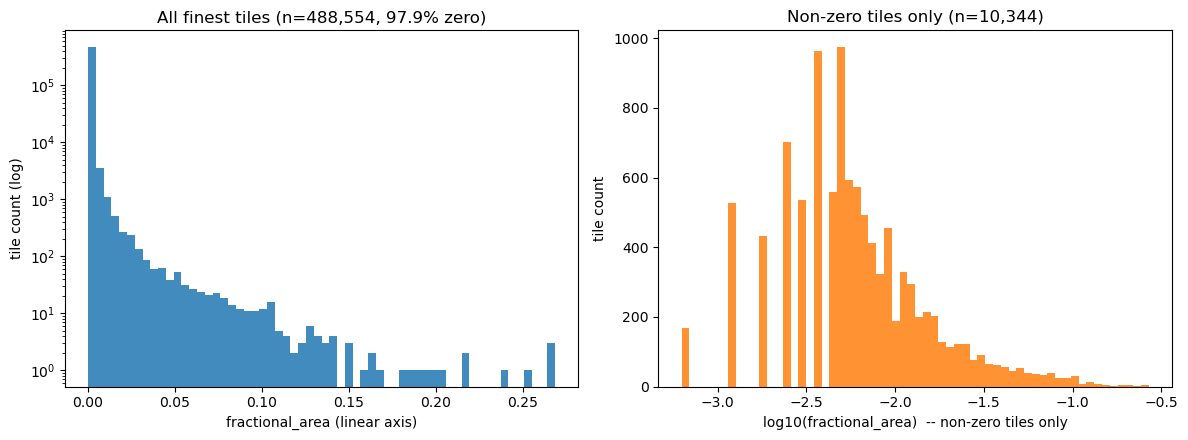

In [4]:
all_finest = pd.concat(
    [load_labels(obs, cfg.output_dir).query('tile_size_px == @s_min') for obs, s_min in
     [(obs, load_provenance(obs, cfg.output_dir)['tile_sizes_px'][0]) for obs in obs_ids]],
    ignore_index=True,
)
fa = all_finest['fractional_area'].to_numpy()
frac_zero = float((fa == 0).mean())
print(f'Total finest tiles: {len(fa):,}')
print(f'Fraction of tiles with boulder_area == 0: {frac_zero:.3%}')
print(f'Mean fractional_area: {fa.mean():.5f}  Median: {np.median(fa):.5f}')
print(f'P90: {np.quantile(fa, 0.9):.5f}  P99: {np.quantile(fa, 0.99):.5f}  Max: {fa.max():.5f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(fa, bins=60, color='tab:blue', alpha=0.85)
axes[0].set_yscale('log')
axes[0].set_xlabel('fractional_area (linear axis)')
axes[0].set_ylabel('tile count (log)')
axes[0].set_title(f'All finest tiles (n={len(fa):,}, {frac_zero:.1%} zero)')

nonzero = fa[fa > 0]
if len(nonzero) > 0:
    axes[1].hist(np.log10(nonzero), bins=60, color='tab:orange', alpha=0.85)
    axes[1].set_xlabel('log10(fractional_area)  -- non-zero tiles only')
    axes[1].set_ylabel('tile count')
    axes[1].set_title(f'Non-zero tiles only (n={len(nonzero):,})')
fig.tight_layout()
fig.savefig(FIG_DIR / '06_target_distribution.png', dpi=110)
plt.show()

## Per-image distribution overlay

The same finest-tile `fractional_area` distribution, broken out by image and shaded by
manifest `BoulderLabel`. Boulder-rich images should sit further right; boulder-poor and
the empty-shapefile diversity pick (ESP_065711_1545) should hug zero.

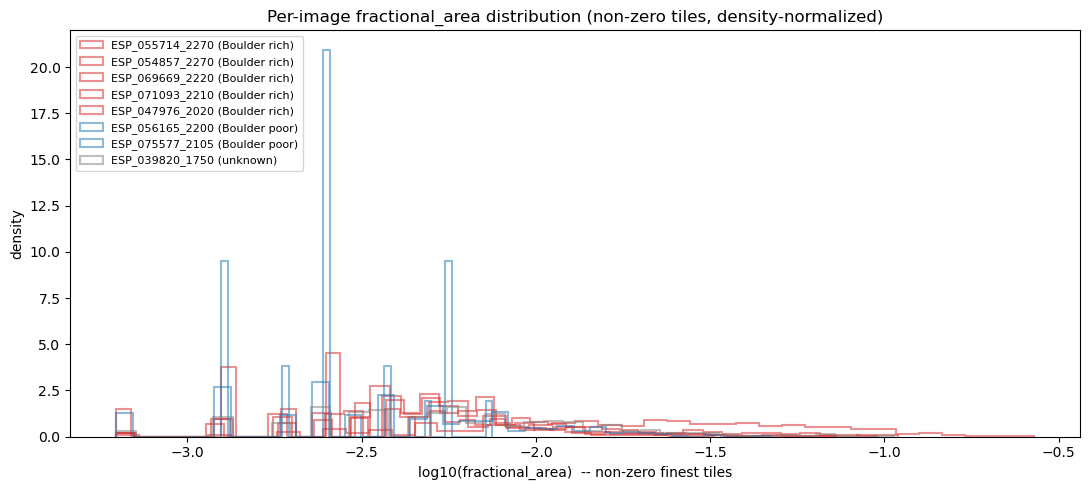

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = {'Boulder rich': 'tab:red', 'Boulder poor': 'tab:blue', 'unknown': 'tab:gray'}
for obs in obs_ids:
    df = load_labels(obs, cfg.output_dir)
    s_min = load_provenance(obs, cfg.output_dir)['tile_sizes_px'][0]
    finest = df[df['tile_size_px'] == s_min]
    fa = finest['fractional_area'].to_numpy()
    nonzero = fa[fa > 0]
    if len(nonzero) == 0:
        continue
    label = manifest_df.set_index('ObsId').loc[obs, 'BoulderLabel']
    ax.hist(np.log10(nonzero), bins=40, alpha=0.5, label=f'{obs} ({label})',
            color=colors.get(label, 'k'), histtype='step', linewidth=1.5, density=True)
ax.set_xlabel('log10(fractional_area)  -- non-zero finest tiles')
ax.set_ylabel('density')
ax.set_title('Per-image fractional_area distribution (non-zero tiles, density-normalized)')
ax.legend(fontsize=8, loc='upper left', ncol=1)
fig.tight_layout()
fig.savefig(FIG_DIR / '06_per_image_distribution.png', dpi=110)
plt.show()

## binary_by_area vs binary_by_count

Each finest tile gets two binary labels emitted by Stage 4:
- `binary_by_area` = (fractional_area >= `labeling.binary_area_threshold`)
- `binary_by_count` = (boulder_count >= `labeling.binary_count_threshold`)

Neither rule has been committed to -- the goal here is to see whether the two agree, and
if not, where they disagree. Tiles where the two labels differ are the interesting cases
(a single big boulder satisfies area-rule but not count-rule, and vice versa).

The contingency table below uses the placeholder thresholds in `config.yaml`
(`binary_area_threshold=0.005`, `binary_count_threshold=5`).  Update those
values + re-run Stage 4 to see the table shift.

Total finest tiles: 488,554
  both True (boulder-rich agreement):      169  (0.03%)
  both False (boulder-poor agreement): 482,879  (98.84%)
  only binary_by_area = True:            5,504  (1.13%)
  only binary_by_count = True:               2  (0.00%)

Contingency table:
binary_by_count   False  True   total
binary_by_area                       
False            482879     2  482881
True               5504   169    5673
total            488383   171  488554


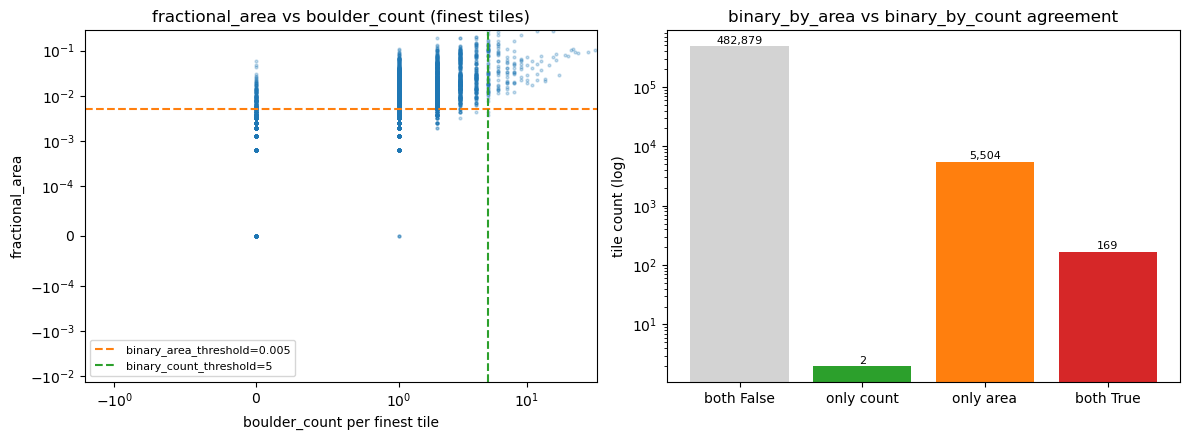

In [6]:
ba = all_finest['binary_by_area'].to_numpy()
bc = all_finest['binary_by_count'].to_numpy()
n = len(ba)
agree_pos = int((ba & bc).sum())
agree_neg = int((~ba & ~bc).sum())
only_area = int((ba & ~bc).sum())
only_count = int((~ba & bc).sum())
print(f'Total finest tiles: {n:,}')
print(f'  both True (boulder-rich agreement):  {agree_pos:>7,}  ({agree_pos/n:.2%})')
print(f'  both False (boulder-poor agreement): {agree_neg:>7,}  ({agree_neg/n:.2%})')
print(f'  only binary_by_area = True:          {only_area:>7,}  ({only_area/n:.2%})')
print(f'  only binary_by_count = True:         {only_count:>7,}  ({only_count/n:.2%})')

ctab = pd.crosstab(
    pd.Series(ba, name='binary_by_area'),
    pd.Series(bc, name='binary_by_count'),
    margins=True, margins_name='total',
)
print('\nContingency table:')
print(ctab)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(all_finest['boulder_count'], all_finest['fractional_area'],
                s=4, alpha=0.25, color='tab:blue')
axes[0].axhline(0.005, color='tab:orange', linestyle='--', label='binary_area_threshold=0.005')
axes[0].axvline(5, color='tab:green', linestyle='--', label='binary_count_threshold=5')
axes[0].set_xlabel('boulder_count per finest tile')
axes[0].set_ylabel('fractional_area')
axes[0].set_xscale('symlog', linthresh=1)
axes[0].set_yscale('symlog', linthresh=1e-4)
axes[0].set_title('fractional_area vs boulder_count (finest tiles)')
axes[0].legend(fontsize=8)

labels_q = ['both False', 'only count', 'only area', 'both True']
values = [agree_neg, only_count, only_area, agree_pos]
colors_q = ['lightgrey', 'tab:green', 'tab:orange', 'tab:red']
axes[1].bar(labels_q, values, color=colors_q)
axes[1].set_ylabel('tile count (log)')
axes[1].set_yscale('log')
for i, v in enumerate(values):
    axes[1].text(i, v * 1.1, f'{v:,}', ha='center', fontsize=8)
axes[1].set_title('binary_by_area vs binary_by_count agreement')
fig.tight_layout()
fig.savefig(FIG_DIR / '06_binary_comparison.png', dpi=110)
plt.show()

## Nested-grid consistency (visual)

Acceptance criterion #2 in CLAUDE.md: summing the finest grid up the x2 ladder must
reproduce the directly-computed coarse-grid stats. This is asserted exactly in
`tests/test_labeling.py::test_stage4_nested_consistency_on_real_data` (passes); here we
look at it visually -- pick one image, downsample its finest heatmap by mean, and compare
against the emitted coarse heatmap. They should be visually indistinguishable.

(Why mean and not sum? `fractional_area` divides by `tile_area`, which is 4x larger at the
coarser scale -- so summing 4 sub-areas and dividing by `4 * tile_area_finest` is the same
as the mean of the 4 sub-fractional-areas.)

C:\Users\brian\AppData\Local\Temp\ipykernel_124660\1996701752.py:28: RuntimeWarning: Mean of empty slice
  g_fine_downsampled = np.nanmean(blocked, axis=(1, 3))


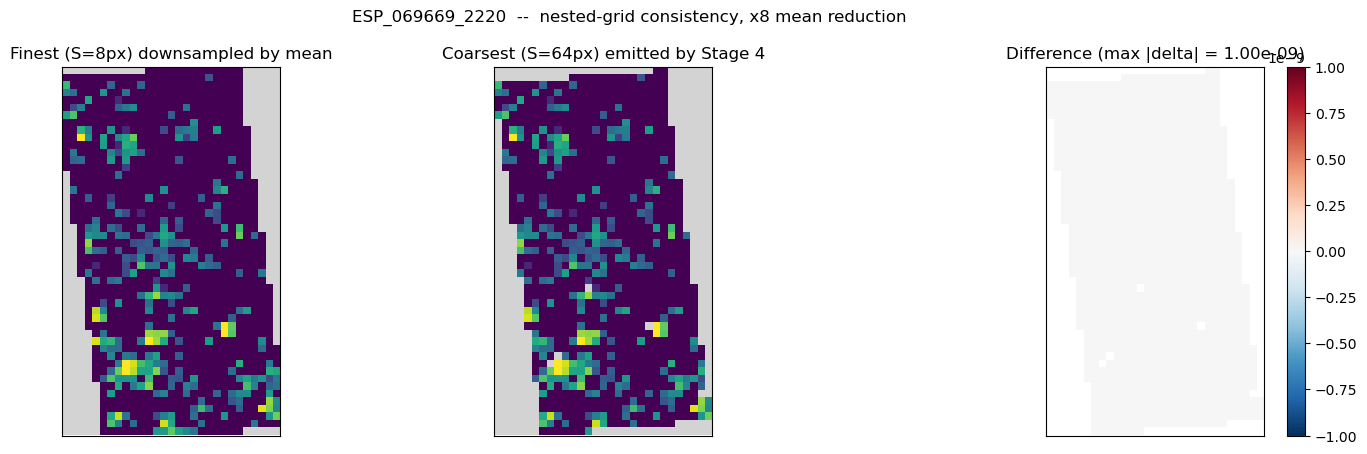


Max |coarse - mean(ratio x ratio finest)| over eligible tiles: 1.000e-09
(Should be 0 to floating-point tolerance; non-zero means nested-grid consistency broke.)


In [7]:
obs_ref = 'ESP_069669_2220' if 'ESP_069669_2220' in obs_ids else obs_ids[0]
df = load_labels(obs_ref, cfg.output_dir)
prov = load_provenance(obs_ref, cfg.output_dir)
sizes = sorted(prov['tile_sizes_px'])
ratio = sizes[-1] // sizes[0]

# Align both grids to the coarsest-grid index origin so cell (i, j) at coarsest
# corresponds to finest cells (i*ratio + di, j*ratio + dj) for di, dj in [0, ratio).
# The finest grid can include cells whose containing coarse tile was dropped (because
# only some of the 4 sub-quartet siblings were eligible across the chain), so we anchor
# on the coarsest index origin and accept NaN cells where finest tiles are missing.
coarse = df[df['tile_size_px'] == sizes[-1]]
ti0_c, ti1_c = int(coarse['ti'].min()), int(coarse['ti'].max())
tj0_c, tj1_c = int(coarse['tj'].min()), int(coarse['tj'].max())
ny_c, nx_c = ti1_c - ti0_c + 1, tj1_c - tj0_c + 1
g_coarse = np.full((ny_c, nx_c), np.nan, dtype=np.float64)
g_coarse[coarse['ti'].to_numpy() - ti0_c, coarse['tj'].to_numpy() - tj0_c] = coarse['fractional_area'].to_numpy()

fine = df[df['tile_size_px'] == sizes[0]]
ny_f, nx_f = ny_c * ratio, nx_c * ratio
g_fine_aligned = np.full((ny_f, nx_f), np.nan, dtype=np.float64)
fi = fine['ti'].to_numpy() - ti0_c * ratio
fj = fine['tj'].to_numpy() - tj0_c * ratio
in_box = (fi >= 0) & (fi < ny_f) & (fj >= 0) & (fj < nx_f)
g_fine_aligned[fi[in_box], fj[in_box]] = fine['fractional_area'].to_numpy()[in_box]

blocked = g_fine_aligned.reshape(ny_c, ratio, nx_c, ratio)
g_fine_downsampled = np.nanmean(blocked, axis=(1, 3))

# Diff = (coarse emitted) - (mean of ratio x ratio finest). Only meaningful where coarse is eligible.
diff = g_coarse - g_fine_downsampled

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
norm = plt.matplotlib.colors.LogNorm(
    vmin=1e-5, vmax=max(float(np.nanpercentile(g_coarse, 99.5)), 1e-4), clip=True,
)
cmap = plt.cm.viridis.copy()
cmap.set_bad(color='lightgrey')
axes[0].imshow(g_fine_downsampled, cmap=cmap, norm=norm)
axes[0].set_title(f'Finest (S={sizes[0]}px) downsampled by mean')
axes[1].imshow(g_coarse, cmap=cmap, norm=norm)
axes[1].set_title(f'Coarsest (S={sizes[-1]}px) emitted by Stage 4')
diff_finite = diff[np.isfinite(diff)]
vmax_d = max(abs(diff_finite).max(), 1e-9) if len(diff_finite) else 1e-9
im2 = axes[2].imshow(diff, cmap='RdBu_r', vmin=-vmax_d, vmax=vmax_d)
axes[2].set_title(f'Difference (max |delta| = {vmax_d:.2e})')
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'{obs_ref}  --  nested-grid consistency, x{ratio} mean reduction')
fig.tight_layout()
fig.savefig(FIG_DIR / f'06_nested_consistency_{obs_ref}.png', dpi=110)
plt.show()
print(f'\nMax |coarse - mean(ratio x ratio finest)| over eligible tiles: {vmax_d:.3e}')
print('(Should be 0 to floating-point tolerance; non-zero means nested-grid consistency broke.)')

## Decisions to revisit after looking at the above

- **`labeling.binary_area_threshold` / `binary_count_threshold`** -- placeholders today
  (0.005 / 5). The contingency table above shows where the two rules disagree; pick the
  thresholds that give the agreement / class balance you want for the modeling stage.
- **`detection_filters.min_confidence`** -- still `null`. The first heatmap-and-distribution
  pass is the place to decide whether the long tail is real boulders or low-confidence
  artifacts. Set in `config.yaml` and re-run `scripts/run_stage4.py --all` (label gen is
  ~3 seconds per image).
- **Whether to keep the empty-shapefile diversity pick (ESP_065711_1545)** -- its tiles all
  carry `fractional_area = 0`, which is genuine ground truth (HiRISE covered, no detections)
  rather than the missing-coverage zero that the mask gate filters out. The modeling stage
  benefits from these true-zero tiles.
- **Stage 3 shift policy for ESP_056165_2200** (peak=0.28, only low-peak image) -- currently
  applying its shift unconditionally. If the heatmap shows the boulder-polygon-overlay looks
  misaligned for this image specifically, consider falling back to nominal for it.